<a href="https://colab.research.google.com/github/Cicel599/patient-appointment-no-show-prediction/blob/main/Notebooks/Notebook_01_Data_Loading%2C_EDA_and_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patient Appointment No-Show Prediction
## Data Loading, EDA, and Preprocessing Pipeline
### COM748 MSc Research Project — Ulster University

**Reference paper:** Hathaway et al. (2025) — *Bringing Precision to Pediatric Care: Explainable AI in Predicting No-Show Trends*

**Dataset:** Medical Appointment No-Show (Netto, 2016) — Kaggle secondary dataset  
**Download:** https://www.kaggle.com/datasets/joniarroba/noshowappointments

---
### Notebook Structure
1. Library imports and configuration
2. Data loading and initial inspection
3. Exploratory Data Analysis (EDA)
4. Data cleaning — erroneous values
5. Feature engineering — replicating Hathaway et al. (2025)
6. Encoding and normalisation
7. Train/test split
8. SMOTE for class imbalance
9. Pipeline summary and save

---
## 1. Library Imports and Configuration

In [ ]:
# =============================================================================
# COM748 MSc Research Project
# Patient Appointment No-Show Prediction
# Section 1 - Library Imports and Configuration
# =============================================================================

# ---------------------------
# Standard Python libraries
# ---------------------------
import os
import warnings

# ---------------------------
# Data manipulation
# ---------------------------
import numpy as np
import pandas as pd

# ---------------------------
# Data visualisation
# ---------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---------------------------
# Machine learning
# ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ---------------------------
# Class imbalance
# ---------------------------
from imblearn.over_sampling import SMOTENC

# =============================================================================
# Global Settings
# =============================================================================

# Hide unnecessary warnings
warnings.filterwarnings("ignore")

# Display settings for Pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot appearance
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "sans-serif",
    "font.size": 11
})

# =============================================================================
# Reproducibility
# =============================================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("=" * 60)
print("Libraries imported successfully")
print("=" * 60)

print(f"Pandas version : {pd.__version__}")
print(f"NumPy version  : {np.__version__}")

print("\nProject configuration")
print(f"Random seed    : {RANDOM_STATE}")
print(f"Test size      : {TEST_SIZE*100:.0f}%")

Libraries imported successfully
Pandas version : 2.2.2
NumPy version  : 2.0.2

Project configuration
Random seed    : 42
Test size      : 20%


---
## 2. Data Loading and Initial Inspection

In [ ]:
# =============================================================================
# Section 2 - Data Loading and Initial Inspection
# =============================================================================

# ---------------------------
# Load dataset
# ---------------------------

DATA_PATH = "KaggleV2-May-2016.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

# Store the original number of rows for later comparison
ORIGINAL_ROWS = len(df)

# ---------------------------
# Standardise column names
# ---------------------------

df.columns = [
    "patient_id",
    "appointment_id",
    "gender",
    "scheduled_day",
    "appointment_day",
    "age",
    "neighbourhood",
    "scholarship",
    "hypertension",
    "diabetes",
    "alcoholism",
    "disability",
    "sms_received",
    "no_show"
]

print("\nColumn names standardised.")
print(df.columns.tolist())

# ---------------------------
# Convert date columns
# ---------------------------

df["scheduled_day"] = pd.to_datetime(df["scheduled_day"])
df["appointment_day"] = pd.to_datetime(df["appointment_day"])

print("\nDate columns converted to datetime format.")

# ---------------------------
# Display first few records
# ---------------------------

print("\nFirst five records")
display(df.head())

# ---------------------------
# Dataset information
# ---------------------------

print("\nDataset information")
print(df.info())

# ---------------------------
# Missing values
# ---------------------------

print("\nMissing values")
missing = df.isnull().sum()

display(
    pd.DataFrame({
        "Missing Values": missing,
        "Percentage": (missing / len(df) * 100).round(2)
    })
)

# ---------------------------
# Descriptive statistics
# ---------------------------

print("\nNumerical summary")
display(df.describe())

print("\nCategorical summary")
display(df.describe(include="object"))

# ---------------------------
# Duplicate records
# ---------------------------

print("\nDuplicate appointment IDs")

duplicate_ids = df.duplicated(subset="appointment_id").sum()

print(f"Duplicate appointment IDs : {duplicate_ids}")

print("\nDataset inspection complete.")

Dataset Loaded Successfully
Rows    : 110,527
Columns : 14

Column names standardised.
['patient_id', 'appointment_id', 'gender', 'scheduled_day', 'appointment_day', 'age', 'neighbourhood', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'disability', 'sms_received', 'no_show']

Date columns converted to datetime format.

First five records


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,disability,sms_received,no_show
0,29872499824296.00,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438.00,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951.00,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174.00,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183.00,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No



Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   patient_id       110527 non-null  float64            
 1   appointment_id   110527 non-null  int64              
 2   gender           110527 non-null  object             
 3   scheduled_day    110527 non-null  datetime64[ns, UTC]
 4   appointment_day  110527 non-null  datetime64[ns, UTC]
 5   age              110527 non-null  int64              
 6   neighbourhood    110527 non-null  object             
 7   scholarship      110527 non-null  int64              
 8   hypertension     110527 non-null  int64              
 9   diabetes         110527 non-null  int64              
 10  alcoholism       110527 non-null  int64              
 11  disability       110527 non-null  int64              
 12  sms_received     110527 non-null  int

,Missing Values,Percentage
patient_id,0,0.00
appointment_id,0,0.00
gender,0,0.00
scheduled_day,0,0.00
appointment_day,0,0.00
age,0,0.00
neighbourhood,0,0.00
scholarship,0,0.00
hypertension,0,0.00
diabetes,0,0.00



Numerical summary


,patient_id,appointment_id,age,scholarship,hypertension,diabetes,alcoholism,disability,sms_received
count,110527.00,110527.00,110527.00,110527.00,110527.00,110527.00,110527.00,110527.00,110527.00
mean,147496265710394.06,5675305.12,37.09,0.10,0.20,0.07,0.03,0.02,0.32
std,256094920291738.88,71295.75,23.11,0.30,0.40,0.26,0.17,0.16,0.47
min,39217.84,5030230.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4172614444192.00,5640285.50,18.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,31731838713978.00,5680573.00,37.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,94391720898175.00,5725523.50,55.00,0.00,0.00,0.00,0.00,0.00,1.00
max,999981631772427.00,5790484.00,115.00,1.00,1.00,1.00,1.00,4.00,1.00



Categorical summary


,gender,neighbourhood,no_show
count,110527,110527,110527
unique,2,81,2
top,F,JARDIM CAMBURI,No
freq,71840,7717,88208



Duplicate appointment IDs
Duplicate appointment IDs : 0

Dataset inspection complete.


---
## 3. Exploratory Data Analysis (EDA)

In [ ]:
# =============================================================================
# Section 3 - Exploratory Data Analysis (EDA)
# =============================================================================

print("=" * 60)
print("Exploratory Data Analysis")
print("=" * 60)

# Create a copy for temporary calculations
eda_df = df.copy()

# Convert target to binary for some analyses
eda_df["target"] = (eda_df["no_show"] == "Yes").astype(int)

Exploratory Data Analysis


### 3.1 Target Variable Distribution


Target Variable Distribution
         Count  Percentage
no_show                   
No       88208       79.80
Yes      22319       20.20


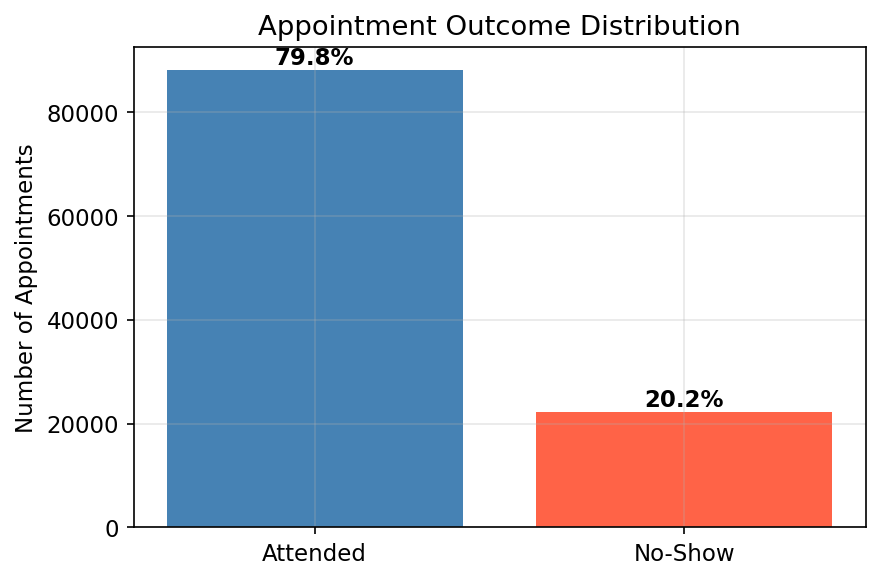

In [ ]:
# =============================================================================
# Target Variable Distribution
# =============================================================================

target_counts = df["no_show"].value_counts()
target_percent = (
    df["no_show"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("\nTarget Variable Distribution")
print(pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
}))

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Attended", "No-Show"],
    target_counts.values,
    color=["steelblue","tomato"]
)

for bar, pct in zip(bars, target_percent):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1000,
        f"{pct:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.title("Appointment Outcome Distribution")
plt.ylabel("Number of Appointments")

plt.tight_layout()
plt.show()

### 3.2 Age Distribution

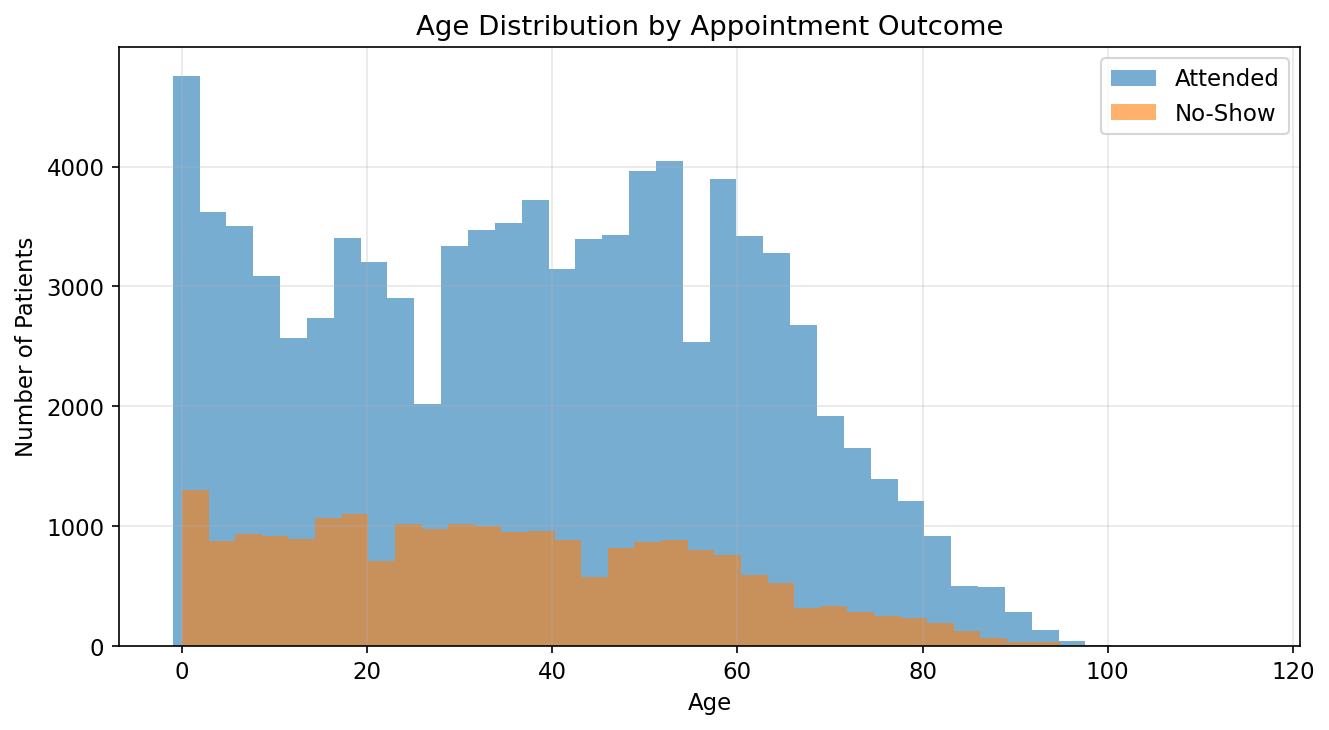

In [ ]:
plt.figure(figsize=(9,5))

plt.hist(
    df.loc[df.no_show=="No","age"],
    bins=40,
    alpha=0.6,
    label="Attended"
)

plt.hist(
    df.loc[df.no_show=="Yes","age"],
    bins=40,
    alpha=0.6,
    label="No-Show"
)

plt.title("Age Distribution by Appointment Outcome")

plt.xlabel("Age")

plt.ylabel("Number of Patients")

plt.legend()

plt.tight_layout()

plt.show()

### 3.3 No-Show Rate by Categorical Variables

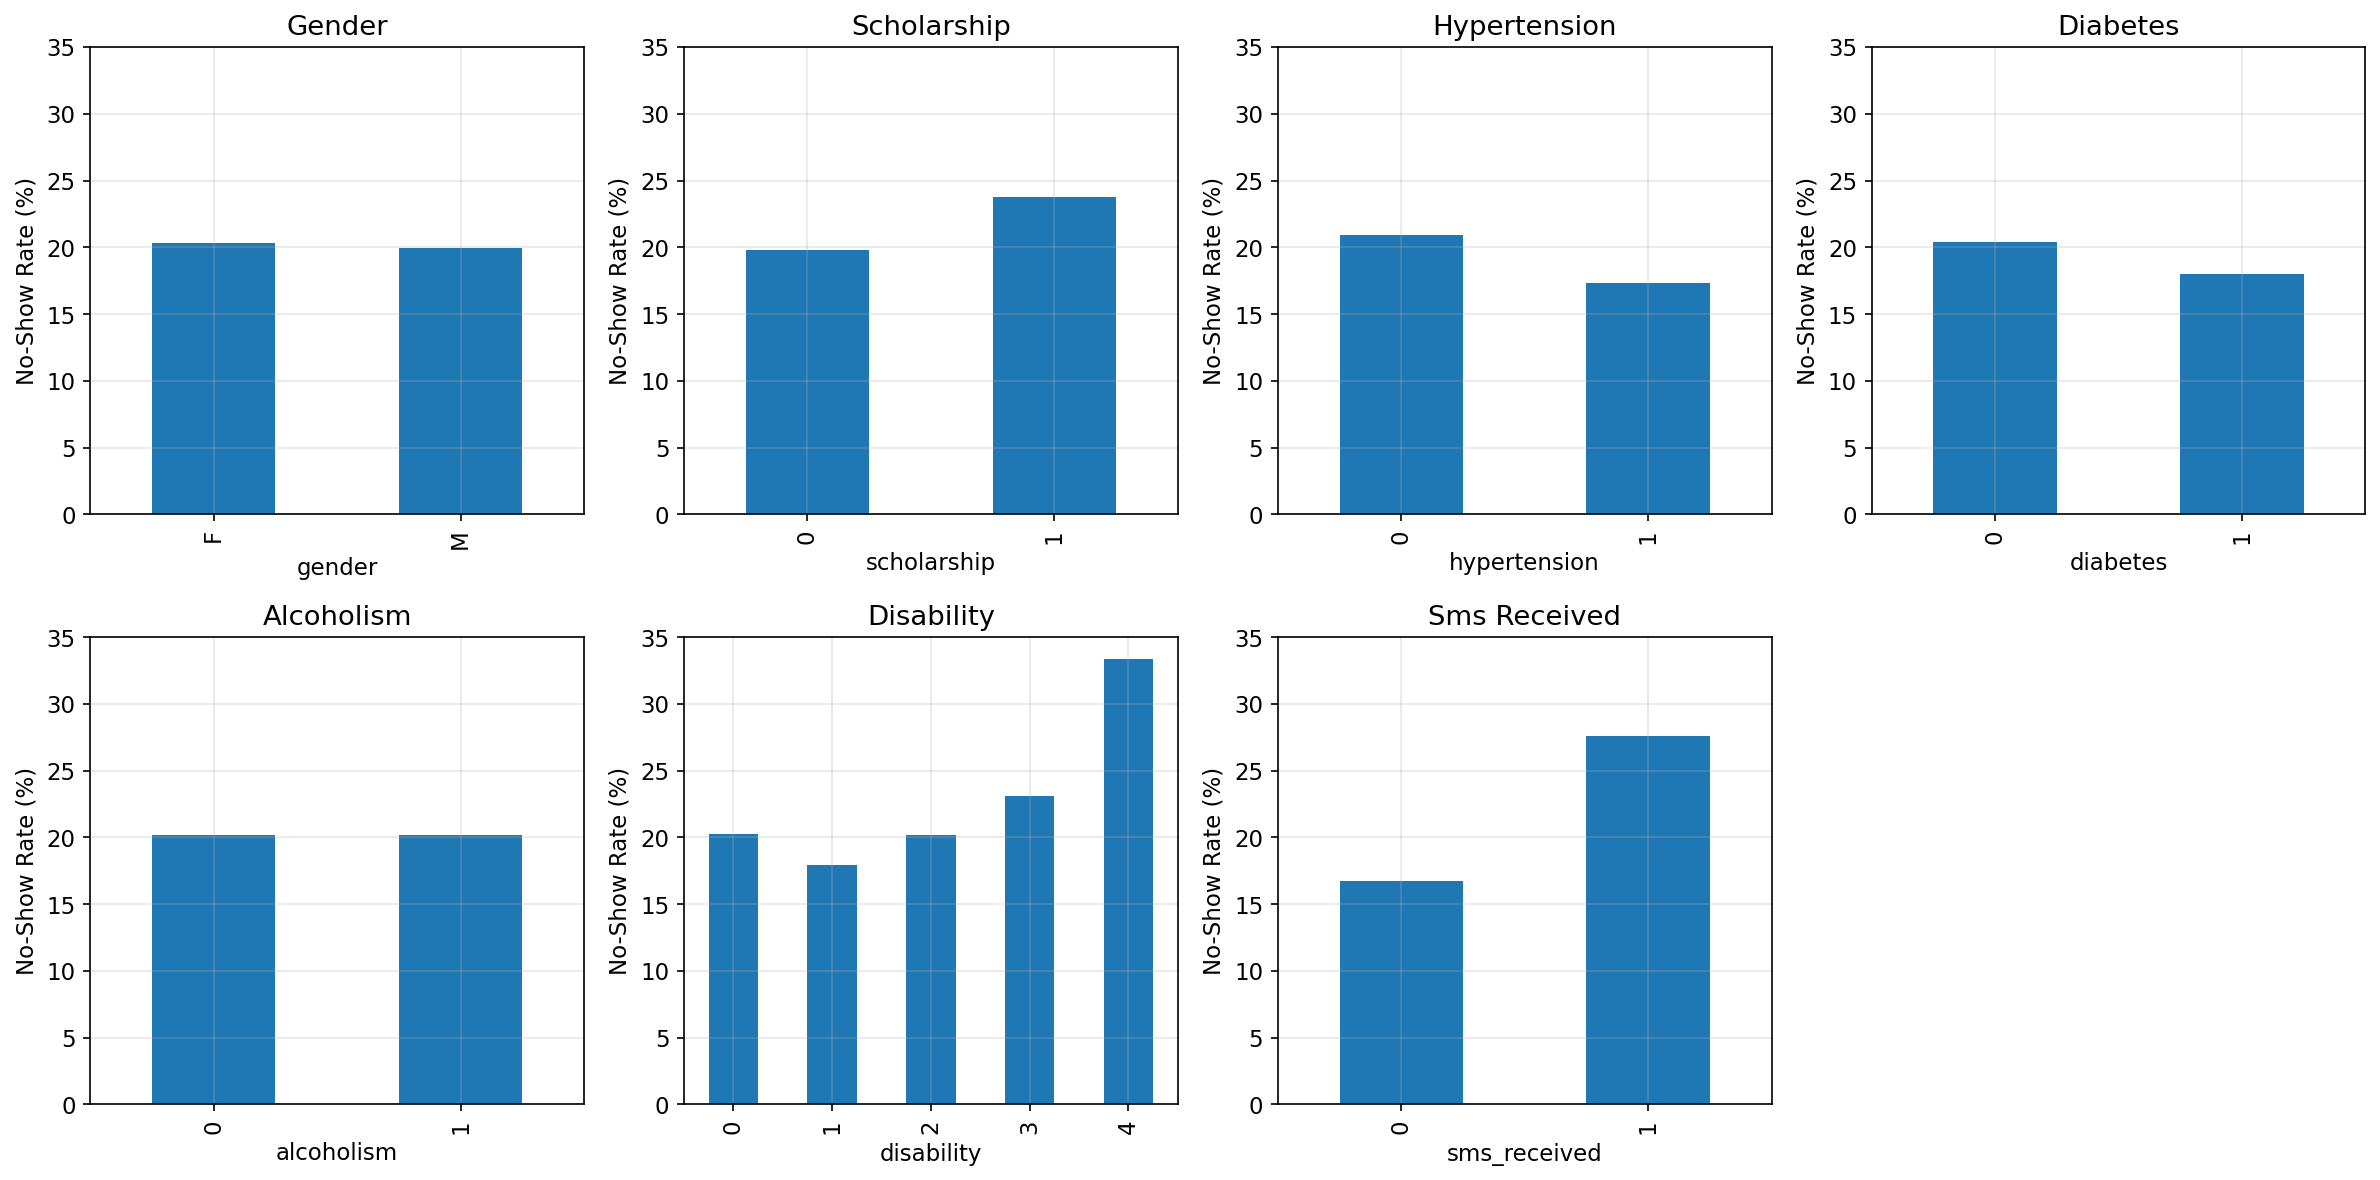

In [ ]:
categorical_features = [

    "gender",
    "scholarship",
    "hypertension",
    "diabetes",
    "alcoholism",
    "disability",
    "sms_received"

]

fig, axes = plt.subplots(2,4, figsize=(16,8))

axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):

    rate = (
        df.groupby(feature)["no_show"]
        .apply(lambda x: (x=="Yes").mean()*100)
    )

    rate.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(feature.replace("_"," ").title())

    ax.set_ylabel("No-Show Rate (%)")

    ax.set_ylim(0,35)

plt.delaxes(axes[-1])

plt.tight_layout()

plt.show()

### 3.4 Correlation Heatmap

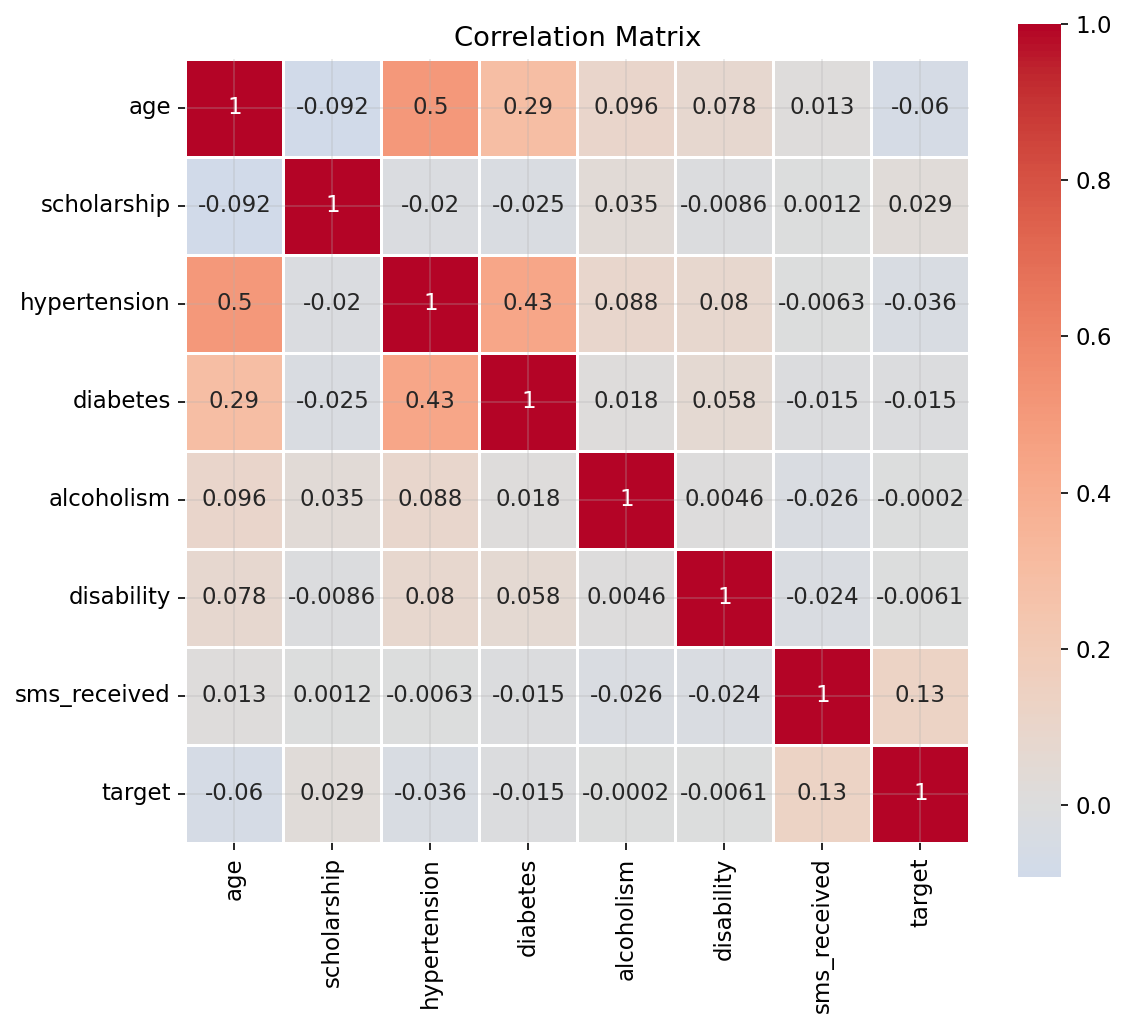

In [ ]:
numerical_features = [

    "age",
    "scholarship",
    "hypertension",
    "diabetes",
    "alcoholism",
    "disability",
    "sms_received",
    "target"

]

corr = eda_df[numerical_features].corr()

plt.figure(figsize=(8,7))

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm",

    center=0,

    square=True,

    linewidths=.5

)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

### 3.5 Appointment Outcome by Age Group

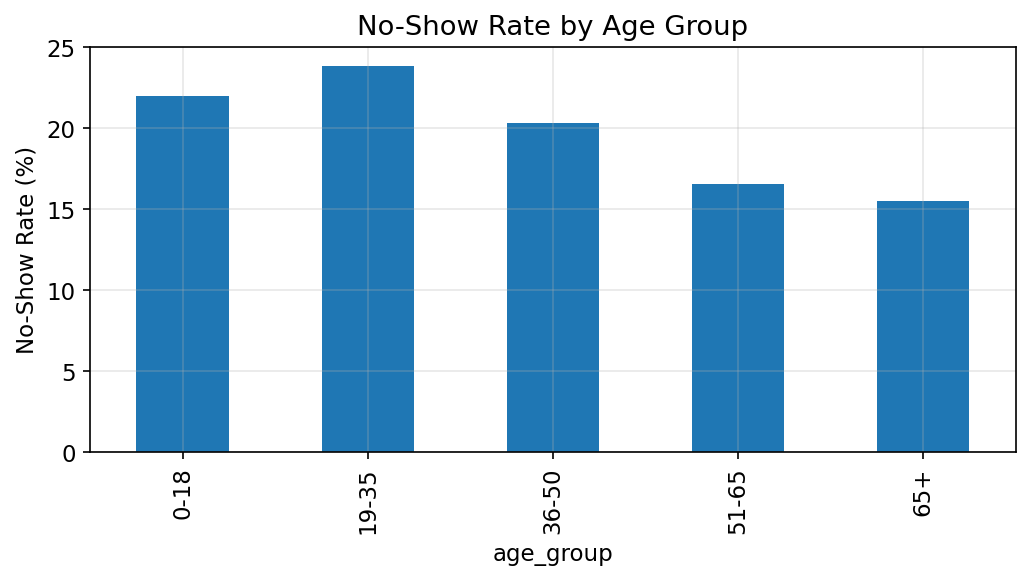

In [ ]:
bins = [0,18,35,50,65,120]

labels = [

    "0-18",

    "19-35",

    "36-50",

    "51-65",

    "65+"

]

eda_df["age_group"] = pd.cut(

    eda_df["age"],

    bins=bins,

    labels=labels,

    include_lowest=True

)

age_group_rate = (

    eda_df.groupby("age_group")["target"]

    .mean()

    *100

)

plt.figure(figsize=(7,4))

age_group_rate.plot(

    kind="bar"

)

plt.ylabel("No-Show Rate (%)")

plt.title("No-Show Rate by Age Group")

plt.tight_layout()

plt.show()

### 3.6 Summary Statistics

In [ ]:
print("="*60)

print("EDA Summary")

print("="*60)

print(f"Appointments         : {len(df):,}")

print(f"Patients             : {df.patient_id.nunique():,}")

print(f"Neighbourhoods       : {df.neighbourhood.nunique()}")

print(f"Average age          : {df.age.mean():.1f}")

print(f"Median age           : {df.age.median():.1f}")

print(f"No-show rate         : {eda_df.target.mean()*100:.1f}%")

EDA Summary
Appointments         : 110,527
Patients             : 62,299
Neighbourhoods       : 81
Average age          : 37.1
Median age           : 37.0
No-show rate         : 20.2%


---
## 4. Data Cleaning — Erroneous Values

Following Hathaway et al. (2025): remove records with biologically implausible values.

In [ ]:
# =============================================================================
# Section 4 - Data Cleaning
# =============================================================================

print("=" * 60)
print("Data Cleaning")
print("=" * 60)

print(f"Original number of records : {ORIGINAL_ROWS:,}")

# Create a copy so the original imported dataset remains unchanged
df_clean = df.copy()

Data Cleaning
Original number of records : 110,527


### Step 1 — Check Missing Values

In [ ]:
# =============================================================================
# Missing Values
# =============================================================================

missing = df_clean.isnull().sum()

print("\nMissing Values")

display(
    pd.DataFrame({
        "Missing": missing,
        "Percentage (%)": (missing / len(df_clean) * 100).round(2)
    })
)


Missing Values


,Missing,Percentage (%)
patient_id,0,0.00
appointment_id,0,0.00
gender,0,0.00
scheduled_day,0,0.00
appointment_day,0,0.00
age,0,0.00
neighbourhood,0,0.00
scholarship,0,0.00
hypertension,0,0.00
diabetes,0,0.00


### Step 2 — Remove Invalid Ages

In [ ]:
# =============================================================================
# Remove Invalid Ages
# =============================================================================

negative_age = (df_clean["age"] < 0).sum()

very_old = (df_clean["age"] > 115).sum()

print(f"\nNegative ages : {negative_age}")

print(f"Age >115      : {very_old}")

df_clean = df_clean[df_clean["age"] >= 0]

df_clean = df_clean[df_clean["age"] <= 115]


Negative ages : 1
Age >115      : 0


### Step 3 — Extract Scheduling Hour (Before Normalising Dates)

In [ ]:
# =============================================================================
# Extract Scheduled Hour
# =============================================================================

df_clean["scheduled_hour"] = df_clean["scheduled_day"].dt.hour

### Step 4 — Create Date-Only Columns

In [ ]:
# =============================================================================
# Create Date Columns
# =============================================================================

df_clean["scheduled_date"] = df_clean["scheduled_day"].dt.normalize()

df_clean["appointment_date"] = df_clean["appointment_day"].dt.normalize()

### Step 5 — Remove Impossible Appointment Dates

In [ ]:
# =============================================================================
# Invalid Appointment Dates
# =============================================================================

invalid_dates = (

    df_clean["appointment_date"]

    <

    df_clean["scheduled_date"]

)

print(f"\nInvalid dates : {invalid_dates.sum()}")

df_clean = df_clean.loc[~invalid_dates].copy()


Invalid dates : 5


### Step 6 — Remove Duplicate Appointment IDs

In [ ]:
# =============================================================================
# Duplicate Appointments
# =============================================================================

duplicates = df_clean.duplicated(

    subset="appointment_id"

)

print(f"Duplicate appointments : {duplicates.sum()}")

df_clean = df_clean.loc[~duplicates].copy()

Duplicate appointments : 0


### Step 7 — Convert Disability to Binary

In [ ]:
# =============================================================================
# Disability Variable
# =============================================================================

df_clean["disability"] = (

    df_clean["disability"] > 0

).astype(int)

### Step 8 — Cleaning Summary

In [ ]:
# =============================================================================
# Cleaning Summary
# =============================================================================

records_removed = ORIGINAL_ROWS - len(df_clean)

print("\nCleaning Summary")

print("-" * 40)

print(f"Original records : {ORIGINAL_ROWS:,}")

print(f"Remaining records: {len(df_clean):,}")

print(f"Records removed  : {records_removed:,}")

print(f"Percentage removed: {records_removed / ORIGINAL_ROWS * 100:.2f}%")


Cleaning Summary
----------------------------------------
Original records : 110,527
Remaining records: 110,521
Records removed  : 6
Percentage removed: 0.01%


---
## 5. Feature Engineering

Replicating the two strongest predictors identified in Hathaway et al. (2025):
1. **Appointment lead time** — days between scheduling and appointment (their strongest predictor, Cohen d = 0.518)
2. **Prior no-show ratio** — per-patient historical no-show rate (their second strongest predictor)

Additional features derived from date columns.

In [ ]:
# =============================================================================
# Section 5 - Feature Engineering
# =============================================================================

print("=" * 60)
print("Feature Engineering")
print("=" * 60)

Feature Engineering


### Step 1 — Appointment Lead Time

In [ ]:
# =============================================================================
# Feature 1 - Appointment Lead Time
# =============================================================================

df_clean["lead_time_days"] = (
    df_clean["appointment_date"]
    - df_clean["scheduled_date"]
).dt.days

print(df_clean["lead_time_days"].describe())

count   110521.00
mean        10.18
std         15.26
min          0.00
25%          0.00
50%          4.00
75%         15.00
max        179.00
Name: lead_time_days, dtype: float64


Prior no-show ratio statistics:
count   110527.00
mean         0.10
std          0.27
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          1.00
Name: prior_noshow_ratio, dtype: float64

Patients with no prior history (ratio=0): 93,025


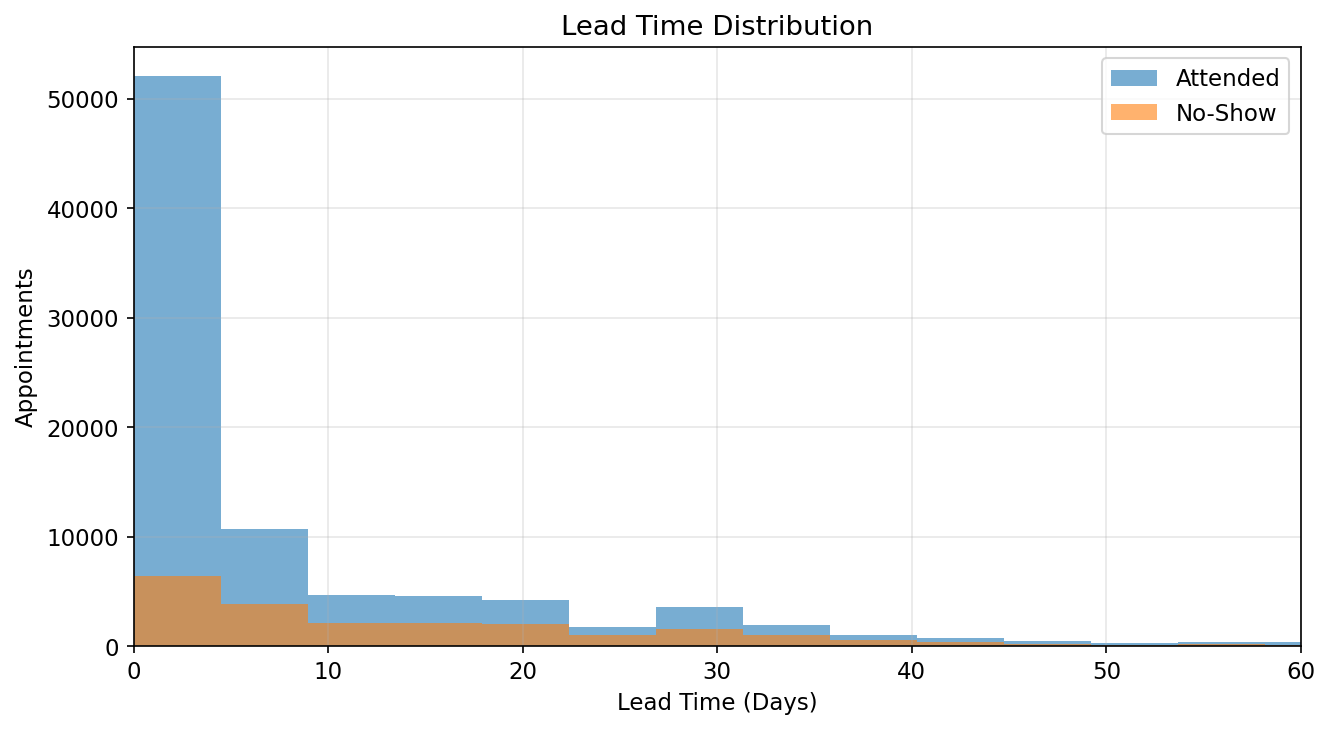

In [ ]:
# ── Feature 2: Prior no-show ratio per patient ────────────────────────────
# Hathaway et al. (2025): second strongest predictor
# METHOD: Sort by scheduled date, then for each row calculate the
# no-show ratio from that patient's PREVIOUS appointments only.
# This prevents data leakage (future appointments do not inform past ones).

df = df.sort_values(['patient_id', 'scheduled_day']).reset_index(drop=True)

def compute_prior_noshow_ratio(group):
    """For each appointment, compute no-show ratio from prior rows only."""
    noshow_binary = (group['no_show'] == 'Yes').astype(int)
    # Cumulative sum shifted by 1 so current row is not included
    cum_noshow = noshow_binary.shift(1).expanding().sum()
    cum_total  = pd.Series(range(len(group)), index=group.index).shift(1) + 1
    ratio = cum_noshow / cum_total
    return ratio.fillna(0)   # First appointment has no history — default 0

df['prior_noshow_ratio'] = (
    df.groupby('patient_id', group_keys=False)
      .apply(compute_prior_noshow_ratio)
)

print('Prior no-show ratio statistics:')
print(df['prior_noshow_ratio'].describe())
print(f'\nPatients with no prior history (ratio=0): {(df["prior_noshow_ratio"]==0).sum():,}')


# Visualise Lead Time
plt.figure(figsize=(9,5))

plt.hist(
    df_clean.loc[df_clean.no_show=="No","lead_time_days"],
    bins=40,
    alpha=0.6,
    label="Attended"
)

plt.hist(
    df_clean.loc[df_clean.no_show=="Yes","lead_time_days"],
    bins=40,
    alpha=0.6,
    label="No-Show"
)

plt.xlim(0,60)

plt.title("Lead Time Distribution")

plt.xlabel("Lead Time (Days)")

plt.ylabel("Appointments")

plt.legend()

plt.tight_layout()

plt.show()

### Step 2 — Prior No-Show Ratio

In [ ]:
#. Sort Chronologically

df_clean = (

    df_clean

    .sort_values(

        ["patient_id","appointment_date"]

    )

    .reset_index(drop=True)

)

In [ ]:
#. Compute Prior No-Show Ratio

def calculate_prior_noshow(group):
    """
    Calculates the historical no-show ratio for each appointment.
    Only appointments occurring before the current appointment
    are included.
    """

    history = (group["no_show"] == "Yes").astype(int)

    previous_noshows = history.shift(1).fillna(0).cumsum()

    previous_visits = np.arange(len(group))

    ratio = np.where(

        previous_visits == 0,

        0,

        previous_noshows / previous_visits

    )

    return pd.Series(ratio, index=group.index)


df_clean["prior_noshow_ratio"] = (

    df_clean

    .groupby("patient_id", group_keys=False)

    .apply(calculate_prior_noshow)

)

### Step 3 — Appointment Day of Week

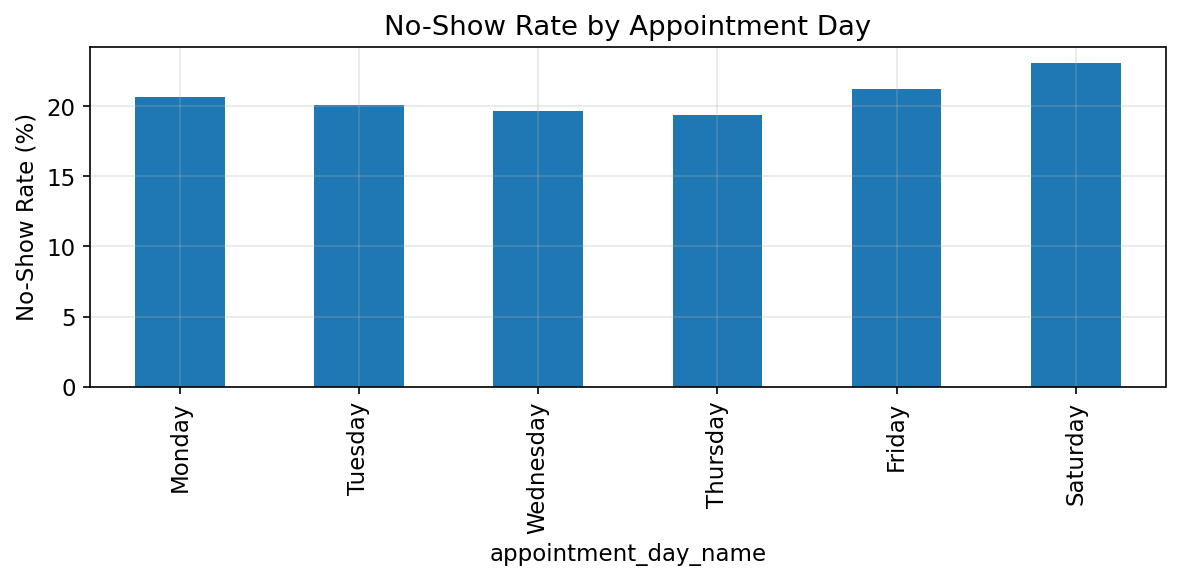

In [ ]:
df_clean["appointment_dow"] = (

    df_clean["appointment_date"]

    .dt.dayofweek

)


# Create Readable Names
#Useful for EDA only.

weekday_names = {

    0:"Monday",

    1:"Tuesday",

    2:"Wednesday",

    3:"Thursday",

    4:"Friday",

    5:"Saturday",

    6:"Sunday"

}

df_clean["appointment_day_name"] = (

    df_clean["appointment_dow"]

    .map(weekday_names)

)

## Visulization

rate = (

    df_clean

    .groupby("appointment_day_name")["no_show"]

    .apply(lambda x:(x=="Yes").mean()*100)

)

rate = rate.reindex([

    "Monday",

    "Tuesday",

    "Wednesday",

    "Thursday",

    "Friday",

    "Saturday"

])

plt.figure(figsize=(8,4))

rate.plot(kind="bar")

plt.ylabel("No-Show Rate (%)")

plt.title("No-Show Rate by Appointment Day")

plt.tight_layout()

plt.show()

### Step 4 — Booking Hour

In [ ]:
df_clean["scheduled_hour"]

print(df_clean["scheduled_hour"].describe())

count   110521.00
mean        10.77
std          3.22
min          6.00
25%          8.00
50%         10.00
75%         13.00
max         21.00
Name: scheduled_hour, dtype: float64


### Step 5 — Review Engineered Features

In [ ]:
engineered = [

    "lead_time_days",

    "prior_noshow_ratio",

    "appointment_dow",

    "scheduled_hour"

]

print(df_clean[engineered].describe())

       lead_time_days  prior_noshow_ratio  appointment_dow  scheduled_hour
count       110521.00           110521.00        110521.00       110521.00
mean            10.18                0.09             1.86           10.77
std             15.26                0.25             1.37            3.22
min              0.00                0.00             0.00            6.00
25%              0.00                0.00             1.00            8.00
50%              4.00                0.00             2.00           10.00
75%             15.00                0.00             3.00           13.00
max            179.00                1.00             5.00           21.00


### Step 6 — Remove Temporary Columns

In [ ]:
df_clean.drop(

    columns=["appointment_day_name"],

    inplace=True

)

### Feature Engineering Summary

In [ ]:
print("="*60)

print("Feature Engineering Complete")

print("="*60)

print("New Features Created")

print("- lead_time_days")

print("- prior_noshow_ratio")

print("- appointment_dow")

print("- scheduled_hour")

Feature Engineering Complete
New Features Created
- lead_time_days
- prior_noshow_ratio
- appointment_dow
- scheduled_hour


---
## 6. Encoding and Feature Preparation

Following Hathaway et al. (2025):
- One-hot encode categorical variables
- Min-Max normalise numerical features to [0, 1]

In [ ]:
# =============================================================================
# Section 6 - Encoding and Feature Preparation
# =============================================================================

print("=" * 60)
print("Encoding and Feature Preparation")
print("=" * 60)

Encoding and Feature Preparation


###. Step 1 — Encode Target Variable

In [ ]:
# =============================================================================
# Encode Target Variable
# =============================================================================

df_clean["target"] = (
    df_clean["no_show"] == "Yes"
).astype(int)

print(df_clean["target"].value_counts())

target
0    88207
1    22314
Name: count, dtype: int64


### Step 2 — Encode Gender

In [ ]:
# =============================================================================
# Gender Encoding
# =============================================================================

df_clean["gender_binary"] = (

    df_clean["gender"] == "F"

).astype(int)

### Step 3 — One-Hot Encode Appointment Day

In [ ]:
# =============================================================================
# Day-of-Week Encoding
# =============================================================================

dow_dummies = pd.get_dummies(

    df_clean["appointment_dow"],

    prefix="dow",

    dtype=int

)

df_clean = pd.concat(

    [df_clean, dow_dummies],

    axis=1

)

### Step 4 — Define Final Feature Set

In [ ]:
# =============================================================================
# Final Features
# =============================================================================

FEATURE_COLUMNS = [

    # Demographics
    "age",
    "gender_binary",

    # Socioeconomic
    "scholarship",

    # Clinical
    "hypertension",
    "diabetes",
    "alcoholism",
    "disability",

    # Appointment information
    "sms_received",
    "lead_time_days",
    "scheduled_hour",

    # Behavioural history
    "prior_noshow_ratio"

]

FEATURE_COLUMNS += list(dow_dummies.columns)

TARGET_COLUMN = "target"

### Step 5 — Create Feature Matrix and Target Vector

In [ ]:
# =============================================================================
# Feature Matrix
# =============================================================================

X = df_clean[FEATURE_COLUMNS].copy()

y = df_clean[TARGET_COLUMN].copy()

print(f"Features : {X.shape}")

print(f"Target   : {y.shape}")

Features : (110521, 17)
Target   : (110521,)


### Step 6 — Identify Numerical Features

In [ ]:
# =============================================================================
# Numerical Columns
# =============================================================================

NUMERICAL_COLUMNS = [

    "age",

    "lead_time_days",

    "scheduled_hour",

    "prior_noshow_ratio"

]

### Step 7 — Identify Categorical Features

In [ ]:
# =============================================================================
# Categorical Columns
# =============================================================================

categorical_columns = [

    "gender_binary",

    "scholarship",

    "hypertension",

    "diabetes",

    "alcoholism",

    "disability",

    "sms_received"

]

categorical_columns += list(dow_dummies.columns)

### Step 8 — Find Their Column Indices

In [ ]:
# =============================================================================
# Categorical Feature Indices
# =============================================================================

categorical_indices = [

    X.columns.get_loc(col)

    for col in categorical_columns

]

print(categorical_indices)

[1, 2, 3, 4, 5, 6, 7, 11, 12, 13, 14, 15, 16]


In [ ]:
SMOTENC(...)

SMOTENC(categorical_features=Ellipsis)

### Step 9 — Review Final Dataset

In [ ]:
print("=" * 60)

print("Final Dataset")

print("=" * 60)

print(f"Number of features : {len(FEATURE_COLUMNS)}")

print(f"Predictors         : {X.shape}")

print(f"Target             : {y.shape}")

print("\nFeatures")

for feature in FEATURE_COLUMNS:

    print(f"• {feature}")

Final Dataset
Number of features : 17
Predictors         : (110521, 17)
Target             : (110521,)

Features
• age
• gender_binary
• scholarship
• hypertension
• diabetes
• alcoholism
• disability
• sms_received
• lead_time_days
• scheduled_hour
• prior_noshow_ratio
• dow_0
• dow_1
• dow_2
• dow_3
• dow_4
• dow_5


---
## 7. Train/Test Split and Feature Scaling

80/20 stratified split — preserves class ratio in both partitions.

**Critical:** SMOTE is applied AFTER this split, on X_train only.
This prevents synthetic test-set samples from contaminating training — the data leakage risk identified by Deina et al. (2024).

In [ ]:
# =============================================================================
# Section 7 - Train/Test Split and Feature Scaling
# =============================================================================

print("=" * 60)
print("Train/Test Split and Feature Scaling")
print("=" * 60)

Train/Test Split and Feature Scaling


### Step 1 — Create Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42

TEST_SIZE = 0.20


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=TEST_SIZE,

    random_state=RANDOM_STATE,

    stratify=y

)

### Step 2 — Check Split Distribution

In [ ]:
print("Training distribution")

print(y_train.value_counts())

print(
    f"No-show rate: {y_train.mean()*100:.2f}%"
)


print("\nTesting distribution")

print(y_test.value_counts())

print(
    f"No-show rate: {y_test.mean()*100:.2f}%"
)

Training distribution
target
0    70565
1    17851
Name: count, dtype: int64
No-show rate: 20.19%

Testing distribution
target
0    17642
1     4463
Name: count, dtype: int64
No-show rate: 20.19%


### Step 3 — Feature Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler


SCALING_COLUMNS = [

    "age",

    "lead_time_days",

    "scheduled_hour",

    "prior_noshow_ratio"

]


scaler = MinMaxScaler()

### Step 4 — Fit Scaler Only on Training Data

In [ ]:
# Fit using training data only

X_train[SCALING_COLUMNS] = scaler.fit_transform(

    X_train[SCALING_COLUMNS]

)


# Apply the same transformation to test data

X_test[SCALING_COLUMNS] = scaler.transform(

    X_test[SCALING_COLUMNS]

)

### Step 5 — Verify Scaling

In [ ]:
print("Scaled Feature Range")

display(

    X_train[SCALING_COLUMNS].describe()

)

Scaled Feature Range


,age,lead_time_days,scheduled_hour,prior_noshow_ratio
count,88416.00,88416.00,88416.00,88416.00
mean,0.32,0.06,0.32,0.09
std,0.20,0.09,0.21,0.25
min,0.00,0.00,0.00,0.00
25%,0.16,0.00,0.13,0.00
50%,0.32,0.02,0.27,0.00
75%,0.48,0.08,0.47,0.00
max,1.00,1.00,1.00,1.00


### Step 6 — Dataset Summary

In [ ]:
print("="*60)

print("Split Complete")

print("="*60)


print(
    f"Training samples : {X_train.shape[0]:,}"
)

print(
    f"Testing samples  : {X_test.shape[0]:,}"
)


print(
    f"Number of features: {X_train.shape[1]}"
)

Split Complete
Training samples : 88,416
Testing samples  : 22,105
Number of features: 17


---
## 8. Handling Class Imbalance Using SMOTENC

**Why SMOTE?**  
No-shows represent ~20% of appointments. Without correction, models achieve high accuracy by predicting attendance for all cases, while completely failing to identify actual no-shows — the clinically important class.

**Applied to training partition only** — never to the test set.  
This is the critical data leakage prevention step highlighted by Deina et al. (2024).

Reference: Chawla et al. (2002) — *SMOTE: Synthetic Minority Over-sampling Technique*

In [ ]:
# =============================================================================
# Section 8 - Handling Class Imbalance Using SMOTENC
# =============================================================================

print("=" * 60)
print("Class Imbalance Handling - SMOTENC")
print("=" * 60)

Class Imbalance Handling - SMOTENC


### Step 1 — Examine Original Class Distribution

In [ ]:
# =============================================================================
# Before SMOTENC
# =============================================================================

print("Before SMOTENC")

before_counts = y_train.value_counts()

print(before_counts)

print(
    f"\nNo-show percentage: {y_train.mean()*100:.2f}%"
)

Before SMOTENC
target
0    70565
1    17851
Name: count, dtype: int64

No-show percentage: 20.19%


### Step 2 — Import and Apply SMOTENC

In [ ]:

# =============================================================================
# Apply SMOTENC
# =============================================================================

smotenc = SMOTENC(

    categorical_features=categorical_indices,

    random_state=RANDOM_STATE

)


X_train_balanced, y_train_balanced = smotenc.fit_resample(

    X_train,

    y_train

)

### Step 4 — Check Balanced Distribution

In [ ]:
print("After SMOTENC")

after_counts = y_train_balanced.value_counts()

print(after_counts)

print(
    f"\nNo-show percentage: {y_train_balanced.mean()*100:.2f}%"
)

After SMOTENC
target
1    70565
0    70565
Name: count, dtype: int64

No-show percentage: 50.00%


### Step 5 — Compare Before and After Balancing

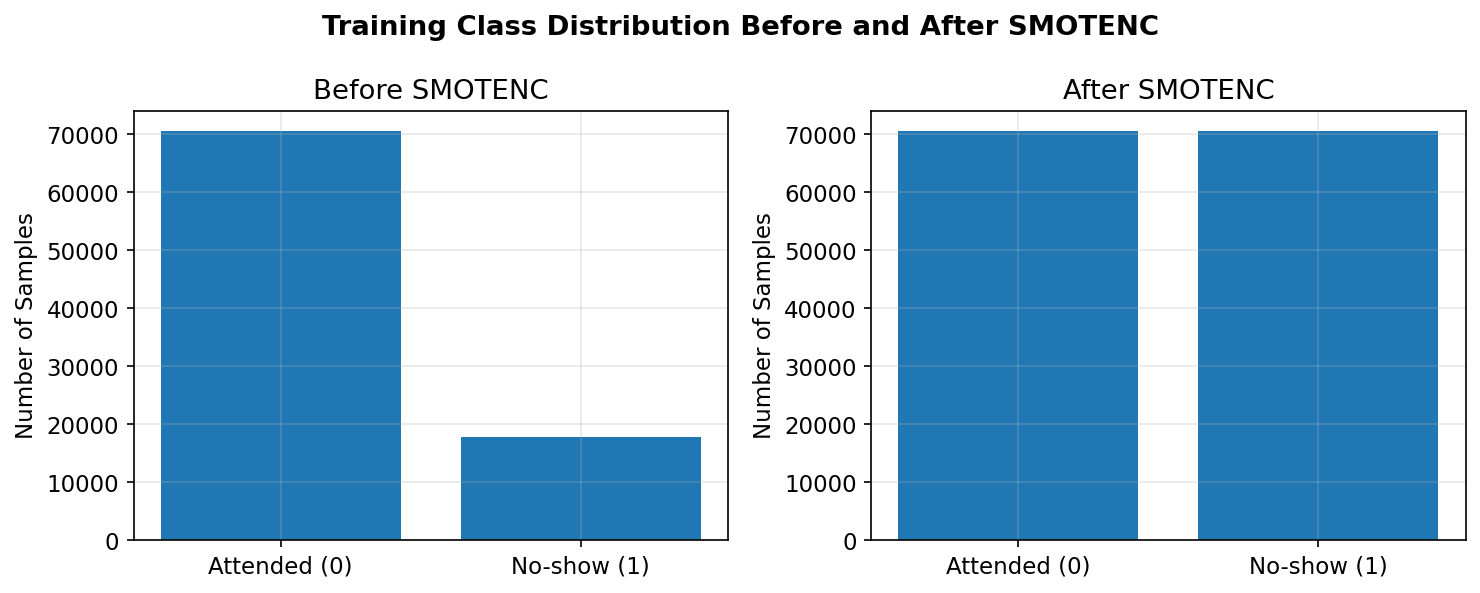

In [ ]:
fig, axes = plt.subplots(

    1,

    2,

    figsize=(10,4)

)


datasets = [

    ("Before SMOTENC", y_train),

    ("After SMOTENC", y_train_balanced)

]


for ax, (title, values) in zip(axes, datasets):

    counts = values.value_counts()

    ax.bar(

        ["Attended (0)", "No-show (1)"],

        [

            counts.get(0,0),

            counts.get(1,0)

        ]

    )

    ax.set_title(title)

    ax.set_ylabel("Number of Samples")


plt.suptitle(

    "Training Class Distribution Before and After SMOTENC",

    fontweight="bold"

)


plt.tight_layout()

plt.show()

### Step 6 — Final Preprocessing Check

In [ ]:
print("="*60)

print("FINAL PREPROCESSING DATASETS")

print("="*60)


print("\nTraining data before balancing")

print(X_train.shape)


print("\nTraining data after SMOTENC")

print(X_train_balanced.shape)


print("\nTesting data")

print(X_test.shape)

FINAL PREPROCESSING DATASETS

Training data before balancing
(88416, 17)

Training data after SMOTENC
(141130, 17)

Testing data
(22105, 17)


---
## 9. Pipeline Summary and Saving Processed Data

In [ ]:
# =============================================================================
# Section 9 - Pipeline Summary and Saving
# =============================================================================

print("=" * 70)
print("FINAL PREPROCESSING PIPELINE SUMMARY")
print("=" * 70)

FINAL PREPROCESSING PIPELINE SUMMARY


### Step 1 — Final Dataset Overview

In [ ]:
print("\nDataset Information")

print("-" * 40)

print(
    f"Original records       : {ORIGINAL_ROWS:,}"
)

print(
    f"Cleaned records        : {len(df_clean):,}"
)

print(
    f"Features created       : {len(FEATURE_COLUMNS)}"
)

print(
    f"Training samples       : {X_train.shape[0]:,}"
)

print(
    f"Balanced training data : {X_train_balanced.shape[0]:,}"
)

print(
    f"Testing samples        : {X_test.shape[0]:,}"
)


Dataset Information
----------------------------------------
Original records       : 110,527
Cleaned records        : 110,521
Features created       : 17
Training samples       : 88,416
Balanced training data : 141,130
Testing samples        : 22,105


### Step 2 — Verify Final Class Distribution

In [ ]:
print("\nClass Distribution")

print("-" * 40)

print("Balanced training set:")

print(y_train_balanced.value_counts())


print("\nTesting set:")

print(y_test.value_counts())


Class Distribution
----------------------------------------
Balanced training set:
target
1    70565
0    70565
Name: count, dtype: int64

Testing set:
target
0    17642
1     4463
Name: count, dtype: int64


### Step 3 — Create Output Directory

In [ ]:
import os
import joblib


OUTPUT_DIR = "data_processed"


os.makedirs(

    OUTPUT_DIR,

    exist_ok=True

)

### Step 4 — Save Training and Testing Data

In [ ]:
# =============================================================================
# Save datasets
# =============================================================================


joblib.dump(

    X_train_balanced,

    f"{OUTPUT_DIR}/X_train_balanced.pkl"

)


joblib.dump(

    y_train_balanced,

    f"{OUTPUT_DIR}/y_train_balanced.pkl"

)


joblib.dump(

    X_test,

    f"{OUTPUT_DIR}/X_test.pkl"

)


joblib.dump(

    y_test,

    f"{OUTPUT_DIR}/y_test.pkl"

)

['data_processed/y_test.pkl']

### Step 5 — Save Preprocessing Objects

In [ ]:
# =============================================================================
# Save preprocessing information
# =============================================================================


joblib.dump(

    scaler,

    f"{OUTPUT_DIR}/scaler.pkl"

)


joblib.dump(

    FEATURE_COLUMNS,

    f"{OUTPUT_DIR}/feature_columns.pkl"

)


joblib.dump(

    categorical_indices,

    f"{OUTPUT_DIR}/categorical_indices.pkl"

)

['data_processed/categorical_indices.pkl']

### Step 6 — Save Clean Dataset

In [ ]:
df_clean.to_csv(

    f"{OUTPUT_DIR}/cleaned_dataset.csv",

    index=False

)

### Step 7 — Display Saved Files

In [ ]:
print("\nSaved Files")

print("-" * 40)


for file in os.listdir(OUTPUT_DIR):

    size = os.path.getsize(

        f"{OUTPUT_DIR}/{file}"

    ) / 1024


    print(

        f"{file:<35} {size:.2f} KB"

    )


Saved Files
----------------------------------------
cleaned_dataset.csv                 20359.14 KB
y_train_balanced.pkl                2205.92 KB
X_test.pkl                          3109.97 KB
feature_columns.pkl                 0.22 KB
scaler.pkl                          1.12 KB
categorical_indices.pkl             0.04 KB
y_test.pkl                          691.57 KB
X_train_balanced.pkl                18746.20 KB


## Final Preprocessing Pipeline Summary

                Raw Kaggle Dataset
                       |
                       ↓
          Data Loading & Inspection
                       |
                       ↓
              Exploratory Analysis
                       |
                       ↓
              Data Cleaning
                       |
                       ↓
          Feature Engineering
                       |
                       ↓
              Encoding Features
                       |
                       ↓
            Train/Test Stratified Split
                       |
                       ↓
              Min-Max Scaling
                       |
                       ↓
                 SMOTENC
                       |
                       ↓
          Saved Modelling Datasets